Nick & Max

In [2]:
#https://www.kaggle.com/datasets/mirichoi0218/insurance

In [3]:
#Importing all necessary libraries required for the XBM GB algorithm
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
#Importing the dataset into the google colab notebook
#This dataset involves customer stats and there insurance charges
#This algorithm will make prediction sets based on their age, sex, etc and predict their insurance charges
from google.colab import files
uploaded=files.upload()
df=pd.read_csv("insurance.csv")
df

Saving insurance.csv to insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
#checking for any nulls in the dataset
#none were detected
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [6]:
#using the label encoder on age, sex, and region
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['sex']=le.fit_transform(df['sex'])
df['smoker']=le.fit_transform(df['smoker'])
df['region']=le.fit_transform(df['region'])

In [7]:
#Setting feature variables and target variable for the algorithm
x = df[['age','sex','bmi','children','smoker','region']]
y = df['charges']

In [8]:
#Creating the dataframe for a better visualization
insurance_df = pd.DataFrame(x, columns = ['age', 'sex', 'bmi', 'children', 'smoker', 'region'])
insurance_df['PredictedInsurance'] = y.values # This will add the target variable or column

#This will print the total samples and number of features
#All the feature names and the first few rows of the dataset
#It will also print the minimum, maximum, mean, and median of the target variable
print(f"Total samples: {len(insurance_df)}")
print(f"Number of features: {len(x.columns)}")
print(f"\nFeature names:")
for i, name in enumerate(x.columns, 1):
    print(f"  {i}.  {name}")
print("\nFirst 5 rows of the dataset:")
print(insurance_df.head())

print("\nTarget variable statistics (Insurance Charges):")
print(f"  Minimum: ${y.min():,.0f}")
print(f"  Maximum: ${y.max():,.0f}")
print(f"  Mean: ${y.mean():,.0f}")
print(f"  Median: ${np.median(y):,.0f}")


Total samples: 1338
Number of features: 6

Feature names:
  1.  age
  2.  sex
  3.  bmi
  4.  children
  5.  smoker
  6.  region

First 5 rows of the dataset:
   age  sex     bmi  children  smoker  region  PredictedInsurance
0   19    0  27.900         0       1       3         16884.92400
1   18    1  33.770         1       0       2          1725.55230
2   28    1  33.000         3       0       2          4449.46200
3   33    1  22.705         0       0       1         21984.47061
4   32    1  28.880         0       0       1          3866.85520

Target variable statistics (Insurance Charges):
  Minimum: $1,122
  Maximum: $63,770
  Mean: $13,270
  Median: $9,382


In [10]:
#This cell will make subset of the data to make the training faster
#Using important features
#It will take a random sample of the original sample set
np.random.seed(50)
sample_indices = np.random.choice(len(x), size=1338, replace=False)

x_simplified = x.iloc[sample_indices]
y_simplified = y.iloc[sample_indices]

print(f"Reduced Dataset Size(Sample): {len(x_simplified)} samples")

Reduced Dataset Size(Sample): 1338 samples


In [13]:
#Splitting  and printing the training set (80%) and testing set (20%)
x_train, x_test, y_train, y_test = train_test_split(
    x_simplified, y_simplified,
    test_size=0.2,
    random_state=42
)

print(f"n\Training set size: {len(x_train)}")
print(f"Testing set size: {len(x_test)}")

n\Training set size: 1070
Testing set size: 268


<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_13795/2874593313.py:7: SyntaxWarning: invalid escape sequence '\T'
  print(f"n\Training set size: {len(x_train)}")


In [17]:
#This will start the XGBoost regressor
#Specifically using it for continous values
#Creating all attributes
model = xgb.XGBRegressor(
    max_depth=4, #max depth of trees
    n_estimators=100, #number of trees
    learning_rate=0.1, #Step size for predictions
    objective='reg:squarederror', #Minimizing squared error
    random_state=42,
    subsample=0.8, #Using 80% of the whole data for each tree produced
    colsample_bytree=0.8 #Using 80% of the features from the data for each tree
)
#Print all the parameters
print("Model parameters:")
print(f"  - Max tree depth: {model.max_depth}")
print(f"  - Number of trees: {model.n_estimators}")
print(f"  - Learning rate: {model.learning_rate}")
print(f"  - Subsample ratio: {model.subsample}")

#Training the model
print("\nTraining in progress...")
model.fit(x_train, y_train, verbose=False)
y_pred = model.predict(x_test)
print("Training complete!")

Model parameters:
  - Max tree depth: 4
  - Number of trees: 100
  - Learning rate: 0.1
  - Subsample ratio: 0.8

Training in progress...
Training complete!


In [18]:
#Printing out the mse and r2 of the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Performance:")
print(f"Mean Squared Error: {mse:,.2f}")
print(f"R^2 Score: {r2:.4f}")


Model Performance:
Mean Squared Error: 18,560,156.66
R^2 Score: 0.8596


In [19]:
#Making the final predictions of the training and testing sets
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

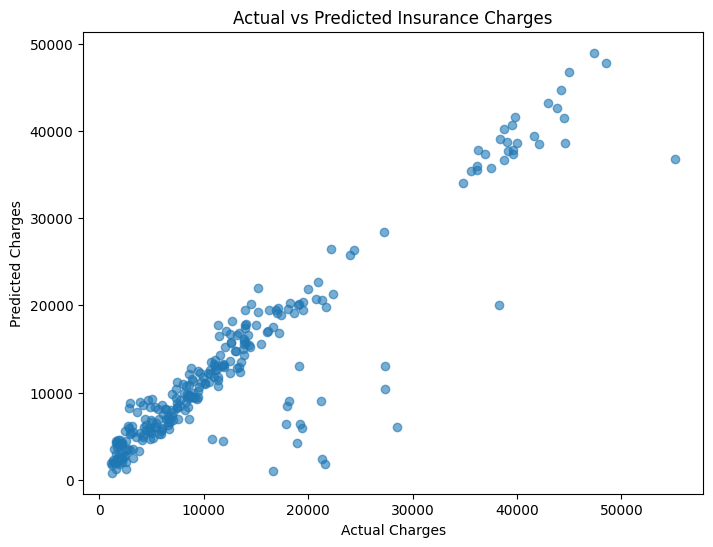

In [20]:
#Making the final graph showing the predicted and actual insurance charges for each customer
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

My partner and I decided to focus on insurance stats from a set of customers. This data was perfect trying to predict insurance charges based on their actual charges. This algorithm uses a randome forest prediction model. It basically uses and implements another algorithm to improve the prediction model. We trained and tested the dataset from these random forests. To make it faster and more efficient, we made this algorithm grab 50 random samples of the dataset to make smaller subset prediction. We applied this to the entire algorithm and made a linear graph to the show the predicted and actual insurance charges.